In [1]:
import sys
print(sys.executable)

/Users/aporter2/qiskit-clean/bin/python


In [2]:
import sys

!{sys.executable} -m pip uninstall -y qiskit qiskit-terra qiskit-aer qiskit-algorithms
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install "qiskit==2.1.1" qiskit-aer qiskit-algorithms

Found existing installation: qiskit 2.1.1
Uninstalling qiskit-2.1.1:
  Successfully uninstalled qiskit-2.1.1
Found existing installation: qiskit-aer 0.17.2
Uninstalling qiskit-aer-0.17.2:
  Successfully uninstalled qiskit-aer-0.17.2
Found existing installation: qiskit-algorithms 0.4.0
Uninstalling qiskit-algorithms-0.4.0:
  Successfully uninstalled qiskit-algorithms-0.4.0
  Using cached qiskit-2.1.1-cp39-abi3-macosx_11_0_arm64.whl.metadata (12 kB)
  Using cached qiskit_aer-0.17.2-cp311-cp311-macosx_11_0_arm64.whl.metadata (8.3 kB)
  Using cached qiskit_algorithms-0.4.0-py3-none-any.whl.metadata (4.7 kB)
Using cached qiskit-2.1.1-cp39-abi3-macosx_11_0_arm64.whl (6.8 MB)
Using cached qiskit_aer-0.17.2-cp311-cp311-macosx_11_0_arm64.whl (2.1 MB)
Using cached qiskit_algorithms-0.4.0-py3-none-any.whl (327 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [qiskit-aer]


In [3]:
import qiskit
import sys

print(sys.executable)
print(qiskit.__version__)
print(qiskit.__file__)

/Users/aporter2/qiskit-clean/bin/python
2.1.1
/Users/aporter2/qiskit-clean/lib/python3.11/site-packages/qiskit/__init__.py


In [4]:
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import EfficientSU2
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA

print("Qiskit is fixed")

Qiskit is fixed


In [5]:
from qiskit.quantum_info import SparsePauliOp
import numpy as np

H_N2 = SparsePauliOp.from_list([
    ("IIII",  2.3186606982640163),
    ("IIXX", -0.397142095845775),
    ("IIYY", -0.397142095845775),
    ("IIIZ", -3.439721180632871),
    ("IZIZ",  2.1499491659313583),
    ("IIZI",  1.2054162485351831),
    ("XXII", -0.397142095845775),
    ("YYII", -0.397142095845775),
    ("IZII", -3.439721180632871),
    ("ZIII",  1.2054162485351831),
])

eigvals, eigvecs = np.linalg.eigh(H_N2.to_matrix())
exact_energy = eigvals[0].real

print(f"Exact ground-state energy: {exact_energy:.12f} eV")

Exact ground-state energy: -5.065838993119 eV


In [6]:
import os, sys

repo_path = "/Users/aporter2/Downloads/nlr_qc/qcaob-aim"
os.chdir(repo_path)

print("Python:", sys.executable)
print("Working directory:", os.getcwd())

Python: /Users/aporter2/qiskit-clean/bin/python
Working directory: /Users/aporter2/Downloads/nlr_qc/qcaob-aim


In [ ]:
import dmft
import vqe
import exact
import anderson_impurity_model as aim

from qiskit.quantum_info import SparsePauliOp

print("Repo imports work")
print("Qiskit imports work")

In [8]:
def openfermion_to_sparse_pauli_op(qubit_operator, num_qubits=None):
    terms = qubit_operator.terms

    if num_qubits is None:
        max_index = -1
        for term in terms:
            for qubit_index, pauli in term:
                max_index = max(max_index, qubit_index)
        num_qubits = max_index + 1

    pauli_list = []

    for term, coeff in terms.items():
        label = ["I"] * num_qubits
        for qubit_index, pauli in term:
            label[num_qubits - 1 - qubit_index] = pauli
        pauli_list.append(("".join(label), complex(coeff)))

    return SparsePauliOp.from_list(pauli_list).simplify()

In [9]:
system_size = 2
seed = 0

(
    impurity_orbital,
    test_model,
    n_orbitals,
    up_qubit_indices,
    down_qubit_indices,
    connected_graphs,
    qubit_hamiltonian
) = dmft.initialize_system(system_size, seed)

qiskit_H = openfermion_to_sparse_pauli_op(qubit_hamiltonian)

print("OpenFermion Hamiltonian:")
print(qubit_hamiltonian)

print("\nQiskit Hamiltonian:")
print(qiskit_H)

OpenFermion Hamiltonian:
(2.3186606982640163+0j) [] +
(-0.397142095845775+0j) [X0 X1] +
(-0.397142095845775+0j) [Y0 Y1] +
(-3.439721180632871+0j) [Z0] +
(2.1499491659313583+0j) [Z0 Z2] +
(1.2054162485351831+0j) [Z1] +
(-0.397142095845775+0j) [X2 X3] +
(-0.397142095845775+0j) [Y2 Y3] +
(-3.439721180632871+0j) [Z2] +
(1.2054162485351831+0j) [Z3]

Qiskit Hamiltonian:
SparsePauliOp(['IIII', 'IIIZ', 'IZII', 'IIZI', 'ZIII', 'IIXX', 'IIYY', 'XXII', 'YYII', 'IZIZ'],
              coeffs=[ 2.3186607 +0.j, -3.43972118+0.j, -3.43972118+0.j,  1.20541625+0.j,
  1.20541625+0.j, -0.3971421 +0.j, -0.3971421 +0.j, -0.3971421 +0.j,
 -0.3971421 +0.j,  2.14994917+0.j])


In [10]:
import numpy as np

eigvals, eigvecs = np.linalg.eigh(qiskit_H.to_matrix())
exact_energy_qiskit = eigvals[0].real

print(f"Qiskit exact energy: {exact_energy_qiskit:.12f} eV")

Qiskit exact energy: -5.065838993119 eV


In [11]:
!grep -n "class .*Qulacs\|def all_symmetry_ansatzae" anderson_impurity_model.py

561:class MeanFieldQulacsVqeEmulator:
670:class SymmQulacsVqeEmulator:
690:    def all_symmetry_ansatzae(self, theta, n_layers, initial_occupations_indices,


In [12]:
!sed -n '680,775p' anderson_impurity_model.py

        #self.spin_charge = None
    
    def checkpoint(self, checkpoint_file):
        # Bind the name of the checkpoint file to the class instance
        self.checkpoint_file = checkpoint_file

    def change_sector(self, spin_charge):
        # Bind the current spin/charge sector to the class instance
        self.spin_charge = spin_charge

    def all_symmetry_ansatzae(self, theta, n_layers, initial_occupations_indices,
                              connected_graphs: dict[str, nx.Graph],
                              compilation="generic"):
        n_qubits = self.hamiltonian.get_qubit_count()
        qc = ParametricQuantumCircuit(n_qubits)
        graph_up, graph_down, graph_stitch = itemgetter("graph_up", "graph_down", "graph_stitch")(connected_graphs)
        if compilation == "generic":
            # Create spin-delineated interaction graphs and reference mappings
            # Instantiates which charge/spin sector we're in
            for inds in initial_occupations_indices:

In [13]:
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector

def repo_symmetry_ansatz_qiskit(
    n_qubits,
    n_layers,
    initial_occupations_indices,
    connected_graphs
):
    graph_up = connected_graphs["graph_up"]
    graph_down = connected_graphs["graph_down"]
    graph_stitch = connected_graphs["graph_stitch"]

    n_params_per_layer = (
        len(list(graph_up.edges()))
        + len(list(graph_down.edges()))
        + len(list(graph_stitch.edges()))
        + n_qubits
    )
    n_params = n_layers * n_params_per_layer

    theta = ParameterVector("θ", n_params)
    qc = QuantumCircuit(n_qubits)

    # initial charge/spin sector
    for q in initial_occupations_indices:
        qc.x(q)

    k = 0

    for _ in range(n_layers):

        # spin-up Givens/SO(4)-style rotations
        for qubit_a, qubit_b in graph_up.edges():
            qc.s(qubit_a)
            qc.s(qubit_b)
            qc.h(qubit_a)
            qc.cx(qubit_a, qubit_b)
            qc.ry(theta[k], qubit_a)
            qc.ry(theta[k], qubit_b)
            k += 1
            qc.cx(qubit_a, qubit_b)
            qc.h(qubit_a)
            qc.sdg(qubit_a)
            qc.sdg(qubit_b)

        # spin-down Givens/SO(4)-style rotations
        for qubit_a, qubit_b in graph_down.edges():
            qc.s(qubit_a)
            qc.s(qubit_b)
            qc.h(qubit_a)
            qc.cx(qubit_a, qubit_b)
            qc.ry(theta[k], qubit_a)
            qc.ry(theta[k], qubit_b)
            k += 1
            qc.cx(qubit_a, qubit_b)
            qc.h(qubit_a)
            qc.sdg(qubit_a)
            qc.sdg(qubit_b)

        # stitch graph ZZ-style rotations
        for qubit_a, qubit_b in graph_stitch.edges():
            qc.cx(qubit_a, qubit_b)
            qc.rz(theta[k], qubit_b)
            qc.cx(qubit_a, qubit_b)
            k += 1

        # final RZ layer
        for q in range(n_qubits):
            qc.rz(theta[k], q)
            k += 1

    return qc, theta

In [14]:
n_qubits = qiskit_H.num_qubits
n_layers = 1

# From your repo output for N=2, charge=2/spin=0 used [0, 2]
initial_occupations_indices = [0, 2]

ansatz, theta = repo_symmetry_ansatz_qiskit(
    n_qubits=n_qubits,
    n_layers=n_layers,
    initial_occupations_indices=initial_occupations_indices,
    connected_graphs=connected_graphs
)

print(ansatz)
print("number of parameters:", ansatz.num_parameters)

     ┌───┐┌───┐┌───┐     ┌──────────┐      ┌───┐ ┌─────┐     ┌───┐┌──────────┐»
q_0: ┤ X ├┤ S ├┤ H ├──■──┤ Ry(θ[0]) ├──■───┤ H ├─┤ Sdg ├─────┤ X ├┤ Rz(θ[2]) ├»
     ├───┤└───┘└───┘┌─┴─┐├──────────┤┌─┴─┐┌┴───┴┐└─────┘┌───┐└─┬─┘├──────────┤»
q_1: ┤ S ├──────────┤ X ├┤ Ry(θ[0]) ├┤ X ├┤ Sdg ├───────┤ X ├──┼──┤ Rz(θ[3]) ├»
     ├───┤┌───┐┌───┐└───┘├──────────┤└───┘└┬───┬┘┌─────┐└─┬─┘  │  └──────────┘»
q_2: ┤ X ├┤ S ├┤ H ├──■──┤ Ry(θ[1]) ├──■───┤ H ├─┤ Sdg ├──┼────■──────────────»
     ├───┤└───┘└───┘┌─┴─┐├──────────┤┌─┴─┐┌┴───┴┐└─────┘  │                   »
q_3: ┤ S ├──────────┤ X ├┤ Ry(θ[1]) ├┤ X ├┤ Sdg ├─────────■───────────────────»
     └───┘          └───┘└──────────┘└───┘└─────┘                             »
«             ┌───┐    ┌──────────┐
«q_0: ────────┤ X ├────┤ Rz(θ[4]) ├
«     ┌───┐   └─┬─┘    ├──────────┤
«q_1: ┤ X ├─────┼──────┤ Rz(θ[5]) ├
«     └─┬─┘     │      ├──────────┤
«q_2: ──┼───────■──────┤ Rz(θ[6]) ├
«       │  ┌──────────┐└──────────┘
«q_3: ──■──┤ Rz(θ[7]) ├─────

In [15]:
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA 
import numpy as np

optimizer = COBYLA(maxiter=1000)
estimator = StatevectorEstimator()

vqe_solver = VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=optimizer
)

vqe_result = vqe_solver.compute_minimum_eigenvalue(qiskit_H)

qiskit_vqe_energy = float(np.real(vqe_result.eigenvalue))

print(f"Exact energy:       {exact_energy_qiskit:.12f} eV")
print(f"Qiskit VQE energy:  {qiskit_vqe_energy:.12f} eV")
print(f"Absolute error:     {abs(qiskit_vqe_energy - exact_energy_qiskit):.6e} eV")
print(f"Relative error:     {abs((qiskit_vqe_energy - exact_energy_qiskit) / exact_energy_qiskit):.6e}")

Exact energy:       -5.065838993119 eV
Qiskit VQE energy:  -5.063005865189 eV
Absolute error:     2.833128e-03 eV
Relative error:     5.592613e-04


In [16]:
import sys
!{sys.executable} -m pip install qiskit-aer

In [17]:
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
import numpy as np

In [18]:
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
import numpy as np

shot_estimator = AerEstimator(
    options={
        "run_options": {
            "shots": 12000,
            "seed_simulator": 0
        }
    }
)

shot_vqe = VQE(
    estimator=shot_estimator,
    ansatz=ansatz,
    optimizer=COBYLA(maxiter=1000)
)

shot_result = shot_vqe.compute_minimum_eigenvalue(qiskit_H)
shot_energy = float(np.real(shot_result.eigenvalue))

print(f"Exact energy:     {exact_energy_qiskit:.12f} eV")
print(f"Shot VQE energy:  {shot_energy:.12f} eV")

Exact energy:     -5.065838993119 eV
Shot VQE energy:  -5.063949508253 eV


In [19]:
import numpy as np
import matplotlib.pyplot as plt

Hmat = qiskit_H.to_matrix()
E0 = exact_energy_qiskit
gs = eigvecs[:, 0]

num_qubits = qiskit_H.num_qubits
I = np.eye(Hmat.shape[0], dtype=complex)

H_shifted = Hmat - E0 * I

In [20]:
def annihilation_op(num_qubits, q):
    dim = 2**num_qubits
    C = np.zeros((dim, dim), dtype=complex)

    for state in range(dim):
        occupied = (state >> q) & 1

        if occupied:
            new_state = state & ~(1 << q)

            # Jordan-Wigner parity factor from lower-index qubits
            parity_count = bin(state & ((1 << q) - 1)).count("1")
            parity = (-1) ** parity_count

            C[new_state, state] = parity

    return C


def creation_op(num_qubits, q):
    return annihilation_op(num_qubits, q).conj().T

In [21]:
impurity_qubit = 0

eta = 0.1
omega = np.linspace(-25, 25, 1000)

c = annihilation_op(num_qubits, impurity_qubit)
cdag = creation_op(num_qubits, impurity_qubit)

phi_plus = cdag @ gs
phi_minus = c @ gs

norm_plus = np.linalg.norm(phi_plus)
norm_minus = np.linalg.norm(phi_minus)

if norm_plus > 1e-12:
    phi_plus = phi_plus / norm_plus

if norm_minus > 1e-12:
    phi_minus = phi_minus / norm_minus

G_exact = np.zeros_like(omega, dtype=complex)

for i, w in enumerate(omega):
    z = w + 1j * eta

    Gp = 0.0 + 0.0j
    Gm = 0.0 + 0.0j

    if norm_plus > 1e-12:
        resolvent_plus = np.linalg.inv(z * I - H_shifted)
        Gp = norm_plus**2 * (phi_plus.conj().T @ resolvent_plus @ phi_plus)

    if norm_minus > 1e-12:
        resolvent_minus = np.linalg.inv((-z) * I - H_shifted)
        Gm = norm_minus**2 * (phi_minus.conj().T @ resolvent_minus @ phi_minus)

    G_exact[i] = Gp - Gm

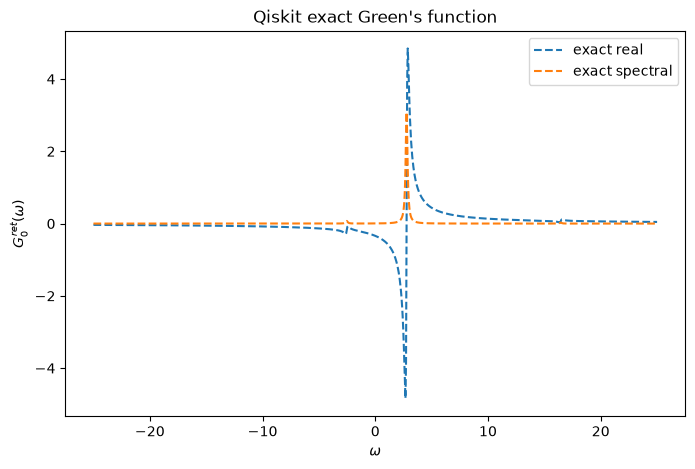

In [22]:
spectral_exact = -1 / np.pi * G_exact.imag

plt.figure(figsize=(8, 5))

plt.plot(omega, G_exact.real, "--", label="exact real")
plt.plot(omega, spectral_exact, "--", label="exact spectral")

plt.xlabel(r"$\omega$")
plt.ylabel(r"$G_0^{ret}(\omega)$")
plt.title("Qiskit exact Green's function")
plt.legend()
plt.show()

In [23]:
from qiskit.quantum_info import Statevector

optimal_params = vqe_result.optimal_point

bound_ansatz = ansatz.assign_parameters(optimal_params)
vqe_state = Statevector.from_instruction(bound_ansatz).data

E_vqe = qiskit_vqe_energy

print(f"VQE energy: {E_vqe:.12f} eV")
print(f"State norm: {np.linalg.norm(vqe_state):.12f}")

VQE energy: -5.063005865189 eV
State norm: 1.000000000000


In [24]:
H_shifted_vqe = Hmat - E_vqe * I

phi_plus_vqe = cdag @ vqe_state
phi_minus_vqe = c @ vqe_state

norm_plus_vqe = np.linalg.norm(phi_plus_vqe)
norm_minus_vqe = np.linalg.norm(phi_minus_vqe)

if norm_plus_vqe > 1e-12:
    phi_plus_vqe = phi_plus_vqe / norm_plus_vqe

if norm_minus_vqe > 1e-12:
    phi_minus_vqe = phi_minus_vqe / norm_minus_vqe

G_vqe = np.zeros_like(omega, dtype=complex)

for i, w in enumerate(omega):
    z = w + 1j * eta

    Gp = 0.0 + 0.0j
    Gm = 0.0 + 0.0j

    if norm_plus_vqe > 1e-12:
        resolvent_plus = np.linalg.inv(z * I - H_shifted_vqe)
        Gp = norm_plus_vqe**2 * (phi_plus_vqe.conj().T @ resolvent_plus @ phi_plus_vqe)

    if norm_minus_vqe > 1e-12:
        resolvent_minus = np.linalg.inv((-z) * I - H_shifted_vqe)
        Gm = norm_minus_vqe**2 * (phi_minus_vqe.conj().T @ resolvent_minus @ phi_minus_vqe)

    G_vqe[i] = Gp - Gm

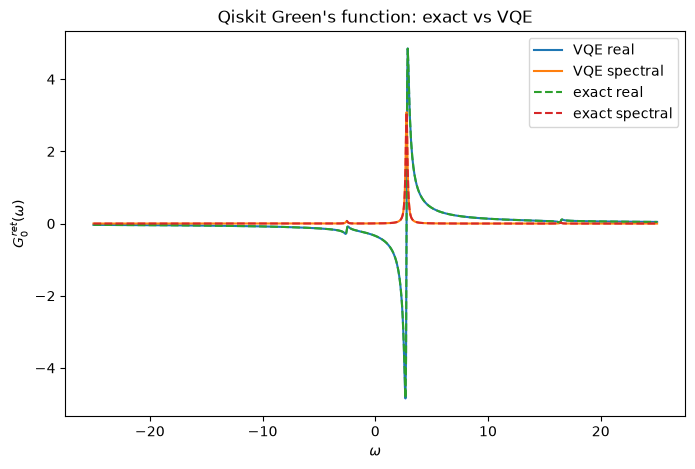

In [25]:
spectral_exact = -1 / np.pi * G_exact.imag
spectral_vqe = -1 / np.pi * G_vqe.imag

plt.figure(figsize=(8, 5))

plt.plot(omega, G_vqe.real, label="VQE real")
plt.plot(omega, spectral_vqe, label="VQE spectral")

plt.plot(omega, G_exact.real, "--", label="exact real")
plt.plot(omega, spectral_exact, "--", label="exact spectral")

plt.xlabel(r"$\omega$")
plt.ylabel(r"$G_0^{ret}(\omega)$")
plt.title("Qiskit Green's function: exact vs VQE")
plt.legend()
plt.show()

In [26]:
gf_relative_error = np.linalg.norm(G_vqe - G_exact) / np.linalg.norm(G_exact)

print(f"GF relative error: {gf_relative_error:.6f}")

GF relative error: 0.020211


In [27]:
system_size = 3
seed = 0

(
    impurity_orbital,
    test_model,
    n_orbitals,
    up_qubit_indices,
    down_qubit_indices,
    connected_graphs,
    qubit_hamiltonian
) = dmft.initialize_system(system_size, seed)

qiskit_H = openfermion_to_sparse_pauli_op(qubit_hamiltonian)

Hmat = qiskit_H.to_matrix()
eigvals, eigvecs = np.linalg.eigh(Hmat)

exact_energy_qiskit = eigvals[0].real
exact_gs = eigvecs[:, 0]

print(f"Exact ground state energy: {exact_energy_qiskit:.12f} eV")
print("Number of qubits:", qiskit_H.num_qubits)

Exact ground state energy: -4.257086675931 eV
Number of qubits: 6


In [28]:
n_qubits = qiskit_H.num_qubits
n_layers = 2

# From repo output for N=3, charge=2/spin=0 sector:
initial_occupations_indices = [0, 3]

ansatz, theta = repo_symmetry_ansatz_qiskit(
    n_qubits=n_qubits,
    n_layers=n_layers,
    initial_occupations_indices=initial_occupations_indices,
    connected_graphs=connected_graphs
)

print("nparams:", ansatz.num_parameters)

nparams: 26


In [29]:
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.quantum_info import Statevector

optimizer = COBYLA(maxiter=1500)
estimator = StatevectorEstimator()

vqe_solver = VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=optimizer
)

vqe_result = vqe_solver.compute_minimum_eigenvalue(qiskit_H)

qiskit_vqe_energy = float(np.real(vqe_result.eigenvalue))

bound_ansatz = ansatz.assign_parameters(vqe_result.optimal_point)
vqe_state = Statevector.from_instruction(bound_ansatz).data

overlap = abs(np.vdot(exact_gs, vqe_state))
gs_error = 1 - overlap

print(f"Exact ground state energy: {exact_energy_qiskit:.12f}")
print(f"Qiskit VQE ground state energy: {qiskit_vqe_energy:.12f}")
print(f"Ground state overlap: {overlap:.12f}")
print(f"Ground state error: {gs_error:.12e}")
print(f"Energy relative error: {abs((qiskit_vqe_energy - exact_energy_qiskit)/exact_energy_qiskit):.6e}")

Exact ground state energy: -4.257086675931
Qiskit VQE ground state energy: -4.252967249590
Ground state overlap: 0.999600606624
Ground state error: 3.993933764112e-04
Energy relative error: 9.676633e-04


In [30]:
def annihilation_op(num_qubits, q):
    dim = 2**num_qubits
    C = np.zeros((dim, dim), dtype=complex)

    for state in range(dim):
        if (state >> q) & 1:
            new_state = state & ~(1 << q)
            parity_count = bin(state & ((1 << q) - 1)).count("1")
            parity = (-1) ** parity_count
            C[new_state, state] = parity

    return C

def creation_op(num_qubits, q):
    return annihilation_op(num_qubits, q).conj().T

In [31]:
eta = 0.1
omega = np.linspace(-25, 25, 1000)

num_qubits = qiskit_H.num_qubits
I = np.eye(Hmat.shape[0], dtype=complex)

impurity_qubit = impurity_orbital

c = annihilation_op(num_qubits, impurity_qubit)
cdag = creation_op(num_qubits, impurity_qubit)

def compute_gf(state, energy):
    H_shifted = Hmat - energy * I

    phi_plus = cdag @ state
    phi_minus = c @ state

    norm_plus = np.linalg.norm(phi_plus)
    norm_minus = np.linalg.norm(phi_minus)

    if norm_plus > 1e-12:
        phi_plus = phi_plus / norm_plus

    if norm_minus > 1e-12:
        phi_minus = phi_minus / norm_minus

    G = np.zeros_like(omega, dtype=complex)

    for i, w in enumerate(omega):
        z = w + 1j * eta

        Gp = 0.0 + 0.0j
        Gm = 0.0 + 0.0j

        if norm_plus > 1e-12:
            Gp = norm_plus**2 * (
                phi_plus.conj().T @ np.linalg.inv(z * I - H_shifted) @ phi_plus
            )

        if norm_minus > 1e-12:
            Gm = norm_minus**2 * (
                phi_minus.conj().T @ np.linalg.inv((-z) * I - H_shifted) @ phi_minus
            )

        G[i] = Gp - Gm

    return G, norm_plus, norm_minus

G_exact, norm_plus_exact, norm_minus_exact = compute_gf(exact_gs, exact_energy_qiskit)
G_vqe, norm_plus_vqe, norm_minus_vqe = compute_gf(vqe_state, qiskit_vqe_energy)

gf_relative_error = np.linalg.norm(G_vqe - G_exact) / np.linalg.norm(G_exact)
gf_avg_relative_diff = np.mean(np.abs(G_vqe - G_exact) / (np.abs(G_exact) + 1e-12))

print("VQE phi_m norm:", norm_minus_vqe)
print("VQE normalized phi_m norm:", 1.0 if norm_minus_vqe > 1e-12 else 0.0)
print("VQE phi_p norm:", norm_plus_vqe)
print("VQE normalized phi_p norm:", 1.0 if norm_plus_vqe > 1e-12 else 0.0)

print("GF numerator:", np.linalg.norm(G_vqe - G_exact))
print("GF denominator:", np.linalg.norm(G_exact))
print("GF relative error:", gf_relative_error)
print("GF avg. relative diff.:", gf_avg_relative_diff)

VQE phi_m norm: 0.4099644919920648
VQE normalized phi_m norm: 1.0
VQE phi_p norm: 0.9121014830081602
VQE normalized phi_p norm: 1.0
GF numerator: 0.5767109915957376
GF denominator: 19.64065887943672
GF relative error: 0.02936311837275172
GF avg. relative diff.: 0.003730035300685712


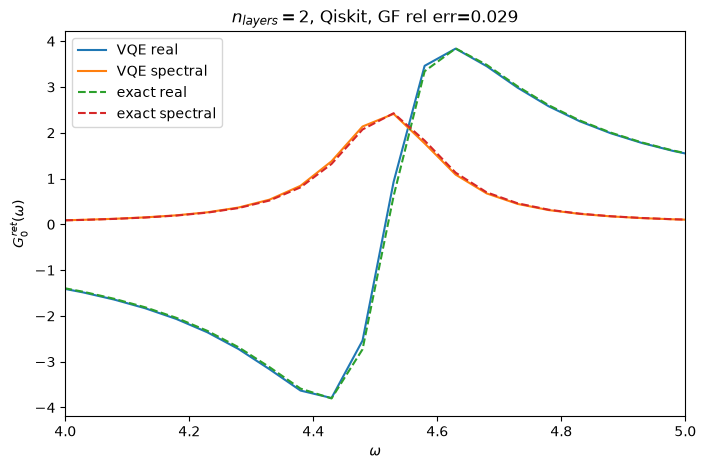

In [32]:
spectral_exact = -1 / np.pi * G_exact.imag
spectral_vqe = -1 / np.pi * G_vqe.imag

plt.figure(figsize=(8, 5))

plt.plot(omega, G_vqe.real, label="VQE real")
plt.plot(omega, spectral_vqe, label="VQE spectral")

plt.plot(omega, G_exact.real, "--", label="exact real")
plt.plot(omega, spectral_exact, "--", label="exact spectral")

plt.xlabel(r"$\omega$")
plt.ylabel(r"$G_0^{ret}(\omega)$")
plt.title(
    rf"$n_{{layers}}={n_layers}$, Qiskit, GF rel err={gf_relative_error:.3f}"
)
plt.legend()
plt.xlim(4,5)
plt.show()

In [33]:
def lanczos_reorth(H, u, niter):
    dim = H.shape[0]
    U = np.zeros((niter + 1, dim), dtype=complex)
    a = np.zeros(niter + 1, dtype=complex)
    b = np.zeros(niter + 1, dtype=complex)

    U[0] = u / np.linalg.norm(u)

    for i in range(niter + 1):
        v = H @ U[i]

        a[i] = np.vdot(U[i], v)

        if i == niter:
            break

        v = v - a[i] * U[i]

        if i > 0:
            v = v - b[i] * U[i - 1]

        # full reorthogonalization
        for j in range(i + 1):
            v = v - np.vdot(U[j], v) * U[j]

        b[i + 1] = np.linalg.norm(v)

        if abs(b[i + 1]) < 1e-12:
            return a[: i + 1], b[: i + 1], U[: i + 1]

        U[i + 1] = v / b[i + 1]

    return a, b, U

In [34]:
def continued_fraction_gf(a, b, z):
    g = 1 / (z - a[-1])

    for i in range(len(a) - 2, -1, -1):
        g = 1 / (z - a[i] - (b[i + 1] ** 2) * g)

    return g

In [35]:
eta = 0.1
omega = np.linspace(-25, 25, 1000)

num_qubits = qiskit_H.num_qubits
I = np.eye(Hmat.shape[0], dtype=complex)

H_shifted_exact = Hmat - exact_energy_qiskit * I

impurity_qubit = impurity_orbital

c = annihilation_op(num_qubits, impurity_qubit)
cdag = creation_op(num_qubits, impurity_qubit)

phi_plus = cdag @ exact_gs
phi_minus = c @ exact_gs

norm_plus = np.linalg.norm(phi_plus)
norm_minus = np.linalg.norm(phi_minus)

if norm_plus > 1e-12:
    phi_plus = phi_plus / norm_plus

if norm_minus > 1e-12:
    phi_minus = phi_minus / norm_minus

print("norm cp:", norm_plus)
print("norm cm:", norm_minus)

norm cp: 0.9119302035227094
norm cm: 0.41034534711999615


In [36]:
niter_plus = 9 if system_size == 3 else min(2**num_qubits - 1, 10)
niter_minus = 3 if system_size == 3 else min(2**num_qubits - 1, 10)

G_lanczos_exact = np.zeros_like(omega, dtype=complex)

if norm_plus > 1e-12:
    a_plus, b_plus, U_plus = lanczos_reorth(H_shifted_exact, phi_plus, niter_plus)
    for i, w in enumerate(omega):
        z = w + 1j * eta
        G_lanczos_exact[i] += norm_plus**2 * continued_fraction_gf(a_plus, b_plus, z)

if norm_minus > 1e-12:
    a_minus, b_minus, U_minus = lanczos_reorth(H_shifted_exact, phi_minus, niter_minus)
    for i, w in enumerate(omega):
        z = w + 1j * eta
        G_lanczos_exact[i] -= norm_minus**2 * continued_fraction_gf(a_minus, b_minus, -z)

print("a_minus:", a_minus.real if norm_minus > 1e-12 else None)
print("b_minus:", b_minus.real if norm_minus > 1e-12 else None)
print("a_plus:", a_plus.real if norm_plus > 1e-12 else None)
print("b_plus:", b_plus.real if norm_plus > 1e-12 else None)

a_minus: [2.29047255 7.9070035  4.3154166 ]
b_minus: [0.         1.24178067 0.29967298]
a_plus: [ 5.30687222 16.48604861  0.78999142  8.27550103 16.76631421  6.73233418
  2.93400361  7.89828239]
b_plus: [0.         3.1889422  2.27597981 1.62596625 4.78165486 1.69601174
 1.54263368 1.2741351 ]


In [37]:
lanczos_vs_inverse_error = np.linalg.norm(G_lanczos_exact - G_exact) / np.linalg.norm(G_exact)

print("Lanczos vs matrix-inverse GF relative error:", lanczos_vs_inverse_error)

Lanczos vs matrix-inverse GF relative error: 5.1533793306256356e-15


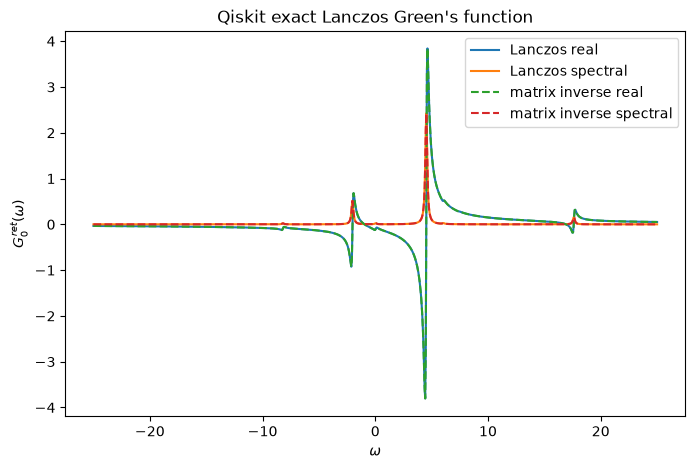

In [38]:
spectral_inverse = -1 / np.pi * G_exact.imag
spectral_lanczos = -1 / np.pi * G_lanczos_exact.imag

plt.figure(figsize=(8, 5))

plt.plot(omega, G_lanczos_exact.real, label="Lanczos real")
plt.plot(omega, spectral_lanczos, label="Lanczos spectral")

plt.plot(omega, G_exact.real, "--", label="matrix inverse real")
plt.plot(omega, spectral_inverse, "--", label="matrix inverse spectral")

plt.xlabel(r"$\omega$")
plt.ylabel(r"$G_0^{ret}(\omega)$")
plt.title("Qiskit exact Lanczos Green's function")
plt.legend()
plt.show()

In [39]:
def lanczos_reorth(H, u, niter):
    dim = H.shape[0]
    U = np.zeros((niter + 1, dim), dtype=complex)
    a = np.zeros(niter + 1, dtype=complex)
    b = np.zeros(niter + 1, dtype=complex)

    U[0] = u / np.linalg.norm(u)

    for i in range(niter + 1):
        v = H @ U[i]
        a[i] = np.vdot(U[i], v)

        if i == niter:
            break

        v = v - a[i] * U[i]

        if i > 0:
            v = v - b[i] * U[i - 1]

        for j in range(i + 1):
            v = v - np.vdot(U[j], v) * U[j]

        b[i + 1] = np.linalg.norm(v)

        if abs(b[i + 1]) < 1e-12:
            return a[: i + 1], b[: i + 1], U[: i + 1]

        U[i + 1] = v / b[i + 1]

    return a, b, U


def continued_fraction_gf(a, b, z):
    g = 1 / (z - a[-1])

    for i in range(len(a) - 2, -1, -1):
        g = 1 / (z - a[i] - (b[i + 1] ** 2) * g)

    return g

In [40]:
def compute_lanczos_gf(state, energy, niter_plus, niter_minus):
    H_shifted = Hmat - energy * I

    phi_plus = cdag @ state
    phi_minus = c @ state

    norm_plus = np.linalg.norm(phi_plus)
    norm_minus = np.linalg.norm(phi_minus)

    if norm_plus > 1e-12:
        phi_plus = phi_plus / norm_plus

    if norm_minus > 1e-12:
        phi_minus = phi_minus / norm_minus

    G = np.zeros_like(omega, dtype=complex)

    a_plus = b_plus = None
    a_minus = b_minus = None

    if norm_plus > 1e-12:
        a_plus, b_plus, _ = lanczos_reorth(H_shifted, phi_plus, niter_plus)

        for i, w in enumerate(omega):
            z = w + 1j * eta
            G[i] += norm_plus**2 * continued_fraction_gf(a_plus, b_plus, z)

    if norm_minus > 1e-12:
        a_minus, b_minus, _ = lanczos_reorth(H_shifted, phi_minus, niter_minus)

        for i, w in enumerate(omega):
            z = w + 1j * eta
            G[i] -= norm_minus**2 * continued_fraction_gf(a_minus, b_minus, -z)

    return G, {
        "norm_plus": norm_plus,
        "norm_minus": norm_minus,
        "a_plus": a_plus,
        "b_plus": b_plus,
        "a_minus": a_minus,
        "b_minus": b_minus,
    }

In [41]:
if system_size == 2:
    niter_plus = 2
    niter_minus = 2
elif system_size == 3:
    niter_plus = 9
    niter_minus = 3
else:
    niter_plus = min(10, 2**num_qubits - 1)
    niter_minus = min(10, 2**num_qubits - 1)

print("niter plus:", niter_plus)
print("niter minus:", niter_minus)

niter plus: 9
niter minus: 3


In [42]:
G_exact_lanczos, exact_lanczos_data = compute_lanczos_gf(
    state=exact_gs,
    energy=exact_energy_qiskit,
    niter_plus=niter_plus,
    niter_minus=niter_minus
)

G_vqe_lanczos, vqe_lanczos_data = compute_lanczos_gf(
    state=vqe_state,
    energy=qiskit_vqe_energy,
    niter_plus=niter_plus,
    niter_minus=niter_minus
)

gf_relative_error = np.linalg.norm(G_vqe_lanczos - G_exact_lanczos) / np.linalg.norm(G_exact_lanczos)
gf_avg_relative_diff = np.mean(
    np.abs(G_vqe_lanczos - G_exact_lanczos) / (np.abs(G_exact_lanczos) + 1e-12)
)

print("VQE a_minus_real:")
print(vqe_lanczos_data["a_minus"].real)

print("VQE b_minus_real:")
print(vqe_lanczos_data["b_minus"].real)

print("VQE a_plus_real:")
print(vqe_lanczos_data["a_plus"].real)

print("VQE b_plus_real:")
print(vqe_lanczos_data["b_plus"].real)

print("GF numerator:", np.linalg.norm(G_vqe_lanczos - G_exact_lanczos))
print("GF denominator:", np.linalg.norm(G_exact_lanczos))
print("GF relative error:", gf_relative_error)
print("GF avg. relative diff.:", gf_avg_relative_diff)

VQE a_minus_real:
[2.28869973 7.88932554 4.3225091 ]
VQE b_minus_real:
[0.         1.24359016 0.37228688]
VQE a_plus_real:
[ 5.29901196 16.5060162   0.86892241 11.84394171 13.59462841  7.34071507
  4.12585725  5.5751594   5.99673972 16.19672977]
VQE b_plus_real:
[0.00000000e+00 3.18336874e+00 2.25268048e+00 2.07180033e+00
 6.12359452e+00 1.51379126e+00 8.43441191e-01 2.55171821e+00
 3.86965084e-02 2.44796661e-10]
GF numerator: 0.5767109915957181
GF denominator: 19.640658879436717
GF relative error: 0.029363118372750737
GF avg. relative diff.: 0.003730035300685676


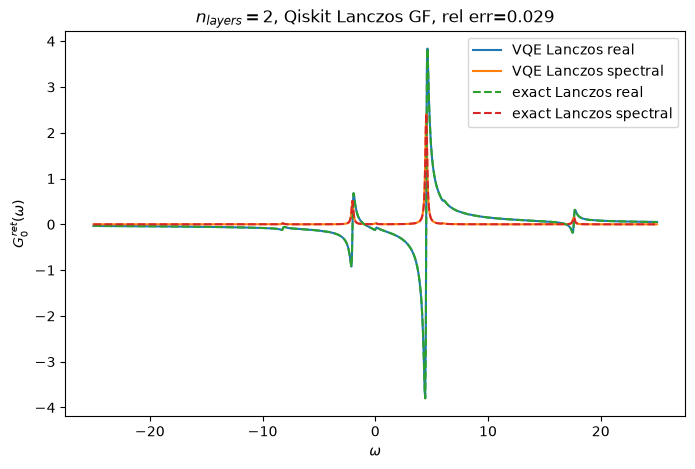

In [43]:
spectral_exact_lanczos = -1 / np.pi * G_exact_lanczos.imag
spectral_vqe_lanczos = -1 / np.pi * G_vqe_lanczos.imag

plt.figure(figsize=(8, 5))

plt.plot(omega, G_vqe_lanczos.real, label="VQE Lanczos real")
plt.plot(omega, spectral_vqe_lanczos, label="VQE Lanczos spectral")

plt.plot(omega, G_exact_lanczos.real, "--", label="exact Lanczos real")
plt.plot(omega, spectral_exact_lanczos, "--", label="exact Lanczos spectral")

plt.xlabel(r"$\omega$")
plt.ylabel(r"$G_0^{ret}(\omega)$")
plt.title(rf"$n_{{layers}}={n_layers}$, Qiskit Lanczos GF, rel err={gf_relative_error:.3f}")
plt.legend()
plt.show()

In [44]:
from qiskit_port.qiskit_vqe import expectation_value, transition_amplitude, overlap

print("qiskit_vqe helpers imported")

qiskit_vqe helpers imported


In [45]:
from qiskit_port.qiskit_vqe import lanczos_cost_function_qiskit

print("Qiskit Lanczos cost function imported")

Qiskit Lanczos cost function imported


In [46]:
import qiskit_port.qiskit_vqe as qv
print(qv.__file__)
print(dir(qv))

/Users/aporter2/Downloads/nlr_qc/qcaob-aim/qiskit_port/qiskit_vqe.py
['Statevector', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '_apply_jordan_wigner_project_flip', 'all_symmetry_ansatzae_qiskit', 'construct_vqe_gs_qiskit', 'continued_fraction_qiskit', 'count_qubits', 'create_qiskit_hamiltonian_matrix', 'expectation_value', 'get_initial_occupations_indices_qiskit', 'get_sparse_operator', 'lanczos_cost_function_qiskit', 'minimize', 'np', 'overlap', 'qulacs_to_python_ordering_qiskit', 'transition_amplitude', 'vqe_gf_pm_qiskit', 'vqe_ideal_lanczos_iterations_qiskit', 'vqe_krylov_zero_state_qiskit']


In [47]:
import importlib
import qiskit_port.qiskit_vqe as qv

importlib.reload(qv)

print("lanczos_cost_function_qiskit" in dir(qv))

True


In [48]:
import importlib
import qiskit_port.qiskit_vqe as qv
importlib.reload(qv)

from qiskit_port.qiskit_vqe import lanczos_cost_function_qiskit
print("import works")

import works


In [ ]:
import numpy as np
import importlib

import dmft
import vqe
import qiskit_port.qiskit_vqe as qv

importlib.reload(qv)

# Build a real AIM system
system_size = 3
seed = 0
vqe_depth = 2

(
    impurity_orbital,
    test_model,
    n_orbitals,
    up_qubit_indices,
    down_qubit_indices,
    connected_graphs,
    qubit_hamiltonian,
) = dmft.initialize_system(system_size, seed)

# First get ground-state information from the repo
record_gs, exact_gs, minimum_angles = dmft.calculate_gs(
    impurity_orbital=impurity_orbital,
    test_model=test_model,
    up_qubit_indices=up_qubit_indices,
    down_qubit_indices=down_qubit_indices,
    connected_graphs=connected_graphs,
    qubit_hamiltonian=qubit_hamiltonian,
    vqe_depth=vqe_depth,
    gs_gtol=5e-4,
    optimizer="COBYLA",
    gtol=5e-4,
    maxiters=100000,
    conv_tol=1e-6,
    display=True,
    gs=True,
)

record_gs.keys()